Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [ ]:
NAME = "Nandish Verma"
COLLABORATORS = "None"

---

Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [ ]:
NAME = "Nandish Verma"
COLLABORATORS = "None"

---

<div class="alert alert-block alert-info">
<h3>Student Information</h3> Please provide information about yourself.<br>
<b>Name</b>:Nandish Verma<br>
<b>NetID</b>:nv274<br>
<b>Notes to Grader</b> (optional):<br>
<br><br>
<b>IMPORTANT</b>
Your work will not be graded withour your initials below<br>
I certify that this lab represents my own work and I have read the RU academic intergrity policies at<br>
<a href="https://www.cs.rutgers.edu/academic-integrity/introduction">https://www.cs.rutgers.edu/academic-integrity/introduction </a><br>
<b>Initials</b>:     


# Lab 4: Multivariate Linear Regression

### Due Date: Wednesday November 29, 2023 on or before 11:59 PM

In this lab we will work through the process of:
1. implementing a linear regression model
2. defining, implementing and testing multiple loss functions 
3. minimizing loss functions using gradient descent
4. comparing with python library functions
5. Using the model to predict on test data 


## Initialize

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)
plt.style.use('fivethirtyeight')
sns.set()
sns.set_context("talk")
%matplotlib inline

# Univariate Linear Regression
In the first task of the lab, we will model linear regression based on a data set that contains housing data (USA_Housing.csv). 

# Task 1 - Initialization
Read the file into a dataframe. We will be doing univariate and multivariate regression on housing data.The goal is to find a model that will allow us to predict hosuing prices given certain values.

### Activity 1.1  Read Data

In [ ]:
import pandas as pd
df=pd.read_csv('/srv/shared/USA_Housing.csv', sep=',')   # do not download the data files as they may change
df
df_adjusted = df.drop('Address', axis=1)# Remove the address column
df_adjusted

### Activity 1.2 Split Data into training and test data sets

In [ ]:
from sklearn.model_selection import train_test_split
## Split the data, df_adjusted into training (90%) and testing (10%) using sklearn
df_training, df_testing = train_test_split(df_adjusted, test_size=0.1, random_state=50)# we will be using test data later in this assignment

### Activity 1.3 Normalize Data
In this task, you need to normalize df_training data using MinMaxScaler from sklearn.preprocessing. Normalize all df_training data columns to be between 0 and 1. X_scaled_values are the normalized x values of housing data and Y_scaled_values are the scaled values of prices.

In [ ]:
### BEGIN ANSWER
from sklearn.preprocessing import MinMaxScaler


### END ANSWER
scaler = MinMaxScaler()
df_training_normalized = pd.DataFrame(scaler.fit_transform(df_training))
# call the scaled vectors x and y
X_scaled_values = df_training_normalized.iloc[:, :5]
Y_scaled_values = df_training_normalized[5]
x = X_scaled_values
y = Y_scaled_values

### Activity 1.4 Plot the features of data to see if a linear regression line is a good fit
It is helpful to understand if the data lends to a good linear regression model. Some features may have more predictive power than others. In this activity, we will plot the points to see if a linear regression line fit to data is reasonable. Plot housing prices vs each of the other features.

#### Plot House Age vs Price

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plot x = "Avg. Area House Age" and y = price
### BEGIN ANSWER
sns.regplot(x = x[1], y = y, line_kws=dict(color="r"))

### END ANSWER

#### Plot number of rooms vs Price

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plot x = "Avg. Area Number of Rooms" and y = price
### BEGIN ANSWER
sns.regplot(x = x[2], y = y, line_kws=dict(color="r"))


### END ANSWER

#### Plot income vs Price

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plot x = "Avg. Area income" and y = price
### BEGIN ANSWER
sns.regplot(x = x[0], y = y, line_kws=dict(color="r"))


### END ANSWER

#### Plot Bedrooms vs Price

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plot x = "Avg. Bedrooms" and y = price
### BEGIN ANSWER
sns.regplot(x = x[3], y = y, line_kws=dict(color="r"))


### END ANSWER

#### Plot Population vs Price

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# plot x = "population" and y = price
### BEGIN ANSWER
sns.regplot(x = x[4], y = y, line_kws=dict(color="r"))


### END ANSWER

## Question 1.5
question: Based on what you see in the plots, what features are good to use in a linear regression model to predict housing prices? Jutify your answers

I think Average Area Income and Average Area House Age would be the best of all features in the dataset to use in a linear regression model because the data points in the plot have the least spread, fitting more closely to the line.

# Task 2 Manual Exploration of Linear Regression Line
In this task we will manually explore the linear regression line for the model x = "Avg. Area House Age" and y = price. This will give us a good intution about the process.
The goal now is to fit a line 
$$
h(\theta) = \theta_0 + \theta_1*x 
$$
to all data points (x,y), such that the L2 error 
$$
 E(\theta) = \sum(h(\theta)-y)^2 $$ is minimized. In this task we will manually change the values of theta0 and theta1 such that we obtain the smallest possible error. 


In [ ]:
# define the function h(theta)
def h(theta0, theta1, x):
    """
    Return the model theta0 + theta1*x
    
    """
    return theta0 + theta1*x

### Activity 2.1 - Define the square loss (L2) function
Define the function, sqerror that computes the error based on the arguments provided. Use the function h(theta) is as defined above. Assume that x and y are the observed vectors. We use the average square loss or L2 loss in this case. 

In [ ]:
import numpy as np

## BEGIN ASNWER
def sqerror(x, y, theta0, theta1):
    """
    Input: parameters theta0 and theta1 of the model
    Input: x, y vectors
    Returns: average L2 square error
    Assumptions: none
    """
    m = len(y)  # Number of data points
    squared_errors = (h(theta0, theta1, x) - y)**2
    L2_error = (1 / m) * np.sum(squared_errors)
    return L2_error
    
    
## END ANSWER

## testing
sqerror(x[0], y, 0.29,0.52)
sqerror(x[1], y, 0.29,0.52)

### Activity 2.2 - Define the L1 Absolute error function
Define the function, abserror that computes the avarega absolute error based on the arguments provided. The function h(theta) is as defined above. Assume that x and y are the observed vectors. We use the average abssolute error in this case.

In [ ]:
import numpy as np
import math

## BEGIN ANSWER
def abserror(x, y, theta0, theta1):
    """
    Input: parameters theta0 and theta1 of the model 
    Input: x, y vectors
    Returns: average L1 error
    Assumptions: none
    """
    m = len(y)  # Number of data points
    absolute_errors = abs(h(theta0, theta1, x) - y)
    L1_error = (1 / m) * np.sum(absolute_errors)
    return L1_error
## END ANSWER

## testing
abserror(x[0], y, 0.29,0.52)
abserror(x[1], y, 0.29,0.52)

### Activity 2.3 - Define the Pseudo Huber loss function
Define the function, huberror that computes the pseudo huber error based on the two arguments provided. The function h(theta) is as defined above. Assume that x and y are the observed vectors. The equation for this function is given by 

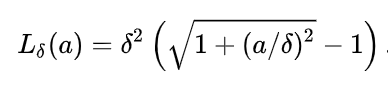

The following function finds the average huber error. In this equation, a  = |h(theta) - y| and delta is a value you can change (see notes for details)

In [ ]:
import numpy as np
import math

## BEGIN ANSWER
def huberror(x, y, theta0, theta1, delta):
    """
    Input: parameters theta0, theta1 and delta of the model 
    Input: x, y vectors
    Returns: psuedo huber error
    Assumptions: none
    """
    m = len(y)  # Number of data points
    a = abs(h(theta0, theta1, x) - y)
    hub_error = (1/m) * (delta**2) * np.sum(a.apply(lambda x: math.sqrt(1+(x/delta)**2)-1))
    return hub_error
    
    

## END ANSWER

## testing
huberror(x[0], y, 0.29,0.52,0.1)
huberror(x[1], y, 0.29,0.52,0.1)

### Activity 2.4 Interactive Exploration.
Let us initialize the interat widget to create sliders that allows us to change the values of theta0 and theta1 and see how things change. Complete the function f below. The function is expected to get two values theta0 and theta1 and plot both the observed points (x,y) and the regression line on the same plot. It also needs to compute the error and display and error.

In [ ]:
from ipywidgets import interact
!jupyter nbextension enable --py widgetsnbextension


In [ ]:
# interactive panel
import pylab
import numpy

def f(theta0, theta1):
    """
    Plot the line and points in an interactive panel
    """
    # plot the line for theta0 and theta1
    y = h(theta0, theta1, x[1]) 
    # compose plot
    pylab.plot(x[1],y) 
    
    # compute the L2 error or sqerr for theta0 and theta1 for 5 decimal places
    l2 = sqerror(x[1], Y_scaled_values, theta0, theta1)
    # compute the absolute or L1 error or abserr for theta0 and theta1
    l1 = abserror(x[1], Y_scaled_values, theta0, theta1)
    # compute the huber error for theta0 and theta1
    hub = huberror(x[1], Y_scaled_values, theta0, theta1, 0.5)
    
    
    # plot the points
    x1 = x[1]   
    y1 = Y_scaled_values
    pylab.title('L1=' + str(abserror(x1, y1, theta0, theta1)) + '  L2=' + str(sqerror(x1, y1, theta0, theta1)) + '  hub=' + str(huberror(x1, y1, theta0, theta1, 0.5)))
    pylab.scatter(x1, y1, alpha=0.5)
    pylab.show() # show the plot  

interact(f, theta1=(0,1,0.1), theta0=(0,1,0.1));


### Activity 2.5 Record the best/smallest values for each error function
Write the "best" values you found for theta0 (y-intercept) and theta1 (slope) and the error. 
This error is the minimum you have observed based on the manual exploration using the widget 
above.

In [ ]:
# BEST VALUES FOR AVE SQUARE ERROR
theta0 = 0.3
theta1 = 0.4
error = 0.016681539486615844
# BEST VALUES FOR AVE ABS ERROR
theta0 = 0.3
theta1 = 0.4
error = 0.10325770447855577

# BEST VALUES FOR AVE HUBER ERROR
theta0 =0.3
theta1 =0.4
error = 0.007979050069431852

# Task 3 - Gradient Descent - Univariate
In this task we use the Gradient descent methods to find a "better" values for theta0 and theta1 that minimizes the error. Gradient descent is an iterative algorithm. It computes values of theta0 and theta1 in the direction of reaching the minimum point in the error function. The iterative formulas using L2 loss function for theta0 and theta1 are given by:
$$
\theta_0 = \theta_0 - \alpha*(\sum(\theta_1*x^j + \theta_0)-y^j)
$$
$$
\theta_1 = \theta_1 - \alpha*(\sum(\theta_1*x^j + \theta_0 - y^j))*x^j
$$

The alpha is called the "learning rate". $(x^j, y^j)$ is the j-th observation. It is important to pick a good value for alpha so that convergence is not too slow (small alpha) or be at the risk of over shooting the minimum point (large alpha). You may have to experiemnt with few alphas to find something that works. When implementing you need to simulataneously compute the values of theta0 and theta1. (do not use a changed theta0 value in computing theta1 in the same iteration.)

### Activity 3.1 Compute Parameters using the Gradient Descent algorithm (L2 loss)

Please print out the theta0 and theta1 values for each iteration in your function. You may get different output compare with the sample output depends on your initial theta0 and theta1 values. We will accept any answers which are close to the sample output.

In [ ]:
# given the observed data (obsX,obsY), learning rate (alpha), and desired error threshold, 
# the function returns theta0 and theta1 when it reaches the error threshold.
# The convergence is reached when the abs(newError - oldError) is less than the threshold.

# BEGIN ANSWER  
def gd2(obsX, obsY, alpha, threshold):
    """
    Input : observed vectors X, Y, alpha and threshold
    Return theta0, theta1 from Gradient Descent L2 loss algorithm
    Return: Iterations and L2 Error
    """
    m = len(obsY)
    theta0 = 0
    theta1 = 0
    prev_error = float('inf')
    current_error = sqerror(obsX, obsY, theta0, theta1)
    iterations = 0
    while abs(prev_error - current_error) > threshold:
        prev_error = current_error
        predictions = h(theta0, theta1, obsX)
        errors = predictions - obsY
        temptheta0 = theta0
        theta0 -= (1/m) * alpha * np.sum((theta1 * obsX + theta0) - obsY)
        theta1 -= (1/m) * alpha * np.sum(obsX*((theta1 * obsX + temptheta0) - obsY))
        current_error = sqerror(obsX, obsY, theta0, theta1)
        iterations += 1
        print(str(iterations) + ', theta0 = ' +str(theta0) +', theta1 = ' + str(theta1) + ', error = '+str(current_error))
    return theta0, theta1, current_error, iterations
    
    
    
# END ANSWER

[theta0,theta1,newError,iterations] = gd2(x[0],y,0.01,0.0001)
print(iterations, newError)

In [ ]:
# observe theta0 and theta1
theta0, theta1

### Activity 3.2 Compute Gradient Descent (Huber)
First Compute a formula for Pseudo huber gradient descent using derivative methods discussed in class and recitation. Similar to L2 descent, use the new formulas (obtained from pseudo huber derivatives) to compute values of theta1, theta1, error. The pseudo huber loss function is provided in Activity 2.3. Use that to differentiate the huber function wrt to theta0 and theta1. 

Please print out the theta0 and theta1 values for each iteration in your function. You may get different output compared with the sample output depending on your initial theta0 and theta1 values. We will accept any answers which are close to the sample output.

In [ ]:
# given the observed data (obsX,obsY), learning rate (alpha), and desired error, 
# the function returns theta0, theta1, error and iterations
# that reaches a minimum error threshold

## BEGIN ANSWER

def gdh(obsX, obsY, alpha, threshold, delta):
    """
    Input : observed vectors X, Y, alpha and threshold
    Return theta0, theta1 from Gradient Descent huber loss algorithm
    Return: Iterations and huber Error
    """
    m = len(obsY)
    theta0 = 0
    theta1 = 0
    prev_error = float('inf')
    current_error = huberror(obsX, obsY, theta0, theta1, delta)
    iterations = 0
    while abs(prev_error - current_error) > threshold:
        prev_error = current_error
        predictions = h(theta0, theta1, obsX)
        errors = predictions - obsY
        temptheta0 = theta0
        theta0 -= (1/m) * alpha * np.sum(theta1 * obsX + theta0 - obsY)
        theta1 -= (1/m) * alpha * np.sum(obsX*((theta1 * obsX + temptheta0) - obsY))
        current_error = huberror(obsX, obsY, theta0, theta1, delta)
        iterations += 1
        print(str(iterations) + ', theta0 = ' +str(theta0) +', theta1 = ' + str(theta1) + ', error = '+str(current_error))
    return theta0, theta1, current_error, iterations
    
## END ANSWER

# testing    
theta0,theta1,newError,iterations = gdh(x[0],y,0.01,0.000001,0.01)
print(iterations, newError)
theta0, theta1

### Activity 3.2
1. Write the values of theta0, theta1, alpha, error that provided the minimum value through gradient descent

159th iteration theta0 = 0.3267072246786318, theta1 = 0.19913547411056406, error = 0.020318011508007047, alpha = 0.0001 for L2 

200th iteration theta0 = 0.3444494636889438, theta1 = 0.21248986287767122, error = 0.0009824613919484516 alpha = 0.0001 for Huber


2. Experiment the new values of theta0, theta1 to see if the interactive widget shows similar things.

similar to what i initially observed with the interactive widget

### Activity 3.3 Compare with Library Estimators
Now use the sklearn LinearRegression module to automate this process. What coefficients do you get? Are they close to what you received from gradient descent? Find the error from sklearn package. Is that error smaller or bigger than the squared error you received?

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
result = lm.fit(x,y)
print(result.intercept_)
print(result.coef_)

In [ ]:
theta0 = result.intercept_
theta1 = result.coef_
sqerror(x[0], y, theta0, theta1[0])
#Its bigger

# Task 4 - Extending the Model to a Bivariate
In this task we extend the model to predict housing price using two features "$x_1 = $Avg. Area House Age" and "$x_2 = $Avg. Area Number of Rooms". The regression model is then defined by  
$$
y = \theta_2*x_2 + \theta_1*x_1 + \theta_0
$$

## Activity 4.1
We need to estimate the values of $\theta_2, \theta_1, \theta_0$. 
The $\theta_0$ formula is given below (using L2 norm). Using the same formating write the formulas for $\theta_1$ and $\theta_2$. The alpha is called the "learning rate". It is important to pick a good value for alpha so that convergence is not too slow (small alpha) or be at the risk of over shooting the minimum point (large alpha). You may have to experiemnt with few alphas to find something that works. 
Refer to class lectures for more help. 

$$
\theta_0 = \theta_0 - \alpha*(\sum(\theta_2*x_2^j + \theta_1*x_1^j + \theta_0)-y^j)
$$



/* write equations for $\theta_1$ and $\theta_2$ here */

$$
\theta_1 = \theta_1 - \alpha*(\sum(\theta_2*x_2^j + \theta_1*x_1^j + \theta_0)-y^j)*x_1^j
$$
$$
\theta_2 = \theta_2 - \alpha*(\sum(\theta_2*x_2^j + \theta_1*x_1^j + \theta_0)-y^j)*x_2^j
$$

## Activity 4.2 Compute Parameters using the Gradient Descent Algorithm (L2 loss)
Print out the $\theta_0$, $\theta_1$ and $\theta_2$ values for each iteration in your function. You may get different outputs depends on your initial choice of $\theta_0$, $\theta_1$ and $\theta_2$ values. We will accept any answers which are close to the sample output.

In [ ]:
# given the observed data (obsX,obsY), learning rate (alpha), and desired error threshold, 
# the function returns theta0, theta1 and theta2 when it reaches the error threshold.
# The convergence is reached when the abs(newError - oldError) is less than the threshold.

# BEGIN ANSWER
def gd22(obsX, obsY, alpha, threshold):
    """
    Input : observed vectors X, Y, alpha and threshold
    Return theta0, theta1, theta2 from Gradient Descent L2 loss algorithm
    Return: Iterations and L2 Error
    """
    m = len(obsY)
    theta0 = 0
    theta1 = 0
    theta2 = 0
    prev_error = float('inf')
    current_error = (1 / m) * np.sum(((theta2 * obsX.iloc[:, 1] + theta1 * obsX.iloc[:, 0] + theta0)-obsY)**2)
    iterations = 0
    while abs(prev_error - current_error) > threshold:
        prev_error = current_error
        predictions = theta2 * obsX.iloc[:, 0] + theta1 * obsX.iloc[:, 1] + theta0
        errors = predictions - obsY
        temptheta0 = theta0
        temptheta1 = theta1
        theta0 -= (1/m) * alpha * np.sum((theta2 * obsX.iloc[:, 1] + theta1 * obsX.iloc[:, 0] + theta0) - obsY)
        theta1 -= (1/m) * alpha * np.sum(obsX.iloc[:, 0]*((theta2 * obsX.iloc[:, 0] + theta1 * obsX.iloc[:, 1] + temptheta0) - obsY))
        theta2 -= (1/m) * alpha * np.sum(obsX.iloc[:, 1]*((theta2 * obsX.iloc[:, 0] + temptheta1 * obsX.iloc[:, 1] + temptheta0) - obsY))
        current_error = (1 / m) * np.sum(((theta2 * obsX.iloc[:, 1] + theta1 * obsX.iloc[:, 0] + theta0)-obsY)**2)
        iterations += 1
        print(str(iterations) + ', theta0 = ' +str(theta0) +', theta1 = ' + str(theta1) + ' , theta2 = '+ str(theta2)+ ', error =' +str(current_error))
    return theta0, theta1, theta2, current_error, iterations
    
    
    
# END ANSWER

[theta0,theta1,theta2, newError,iterations] = gd22(x[[1,2]],y,0.01,0.00000001)
print(iterations)

Write the values of thetas obtained from function above.
$$\theta_0 = 0.2282230703957341$$ 
$$\theta_1 = 0.37251968257808954$$ 
$$\theta_2 = 0.17629643213594248$$ 
and write the model 
$$
y = \theta_2*x_2 + \theta_1*x_1 + \theta_0
$$

## Activity 4.3 Compare Coefficients with Library Estimators
Now use the sklearn LinearRegression module to automate the process of finding coefficients. 

In [ ]:
# fit a regression model
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# assume
#y = df_training.Price
#X = df_training[["Avg. Area House Age","Avg. Area Number of Rooms"]]

model = LinearRegression().fit(x[[1,2]], y)
model
print(model.coef_)
model.intercept_

What coefficients do you get? Are they close to what you received from gradient descent? ]Is that error smaller or bigger than the squared error you received?

##### Begin Answer
[0.45718158, 0.36702939] are the coefficients. They are larger than what I got from my gradient descent function. The error is larger than my error of 0.0198.

##### End Answer

## Activity 4.4.1 - Predict the Housing Price using test set data - gradient descent
Use the test set to find the estimated value of the home $y$ using coefficients received from gradient descent. Defined the average error as 1/m * $\sum$ abs(predicted - actual) where m is the size of the test data set.

In [ ]:
## Begin ANSWER
m = len(y)
absolute_error = abs((theta2 * x[2] + theta1 * x[1] + theta0)-y)
average_error = (1 / m) * np.sum(absolute_error)


## End ANSWER
error_gd = average_error
error_gd

## Activity 4.4.2 - Predict the Housing Price using test set data - library estimator
Use the test set to find the estimated value of the home $y$ using coefficients received from library estimators. Defined the averge error as 1/m * $\sum$ abs(predicted - actual) where m is the size of the test data set.

In [ ]:
## Begin ANSWER
libthetas = model.coef_
lib_absolute_error = abs((libthetas[1] * x[2] + libthetas[0] * x[1] + model.intercept_)-y)
lib_average_error = (1 / m) * np.sum(lib_absolute_error)

## End ANSWER
error_lib = lib_average_error
error_lib

## Activity 4.4.3
Compare the performance of Gradient Descent and Library Estimators. Briefly explain your observations and if there are significant descrepancies, explain them in your own words. Do you think either model would be a reasonable model for predicting home prices for new homes on the market? Why or Why not.



The average error from the library estimator is smaller than the average error from my gradient descent algorithm. The library estimator average error is 0.09503004292447578 and my gradient descent average error is 0.09784981188493483. This can be explained by my gradient descent algorithm having an alpha of 0.00000001 while the library estimator is more precise. I think either of them are reasonable models to use with an acceptable average error, but I would obviously prefer to use the one with the smaller average error, which is the Library Estimator.

### Feedback
Please provide feedback on this lab.
* how would you rate this lab (from 1-lowest, 10-highest) : 5
* how can we improve his lab? : format it correctly

<div class="alert alert-block alert-info">
<h2>Submission Instructions</h2> 
<b> File Name:</b> Please name the file as your_section_your_netID_lab5.jpynb<br>
<b> Submit To: </b> codebench <br>
<b>Warning:</b> Failure to follow directions may result in loss points.<br>
</div>

@2023 All Rights Reserved. Lab Developed by A.D. Gunawardena for CS 439. DO NOT post a copy of this lab or solutions in public space such as github or on commercial sites. 